# 📊 신입 데이터 분석가 취업 준비 — 잡코리아 공고 분석

> 잡코리아 "데이터분석" 키워드 검색 결과 250개 공고를 분석하여  
> **신입 데이터 분석가로 취업하기 위해 무엇을 준비해야 하는지** 파악합니다.

## 분석 목차
1. 데이터 로딩 & 기본 탐색  
2. 데이터 정제 — 중복 제거 & 실제 분석 직무 필터링  
3. 경력 요건 분포 — 신입 지원 가능 비율  
4. 지역별 분포  
5. 기술스택(스킬) 분석 — 가장 많이 요구되는 기술  
6. 우대 자격증 분석  
7. 우대 조건 키워드 분석  
8. 핵심역량 분석  
9. 급여 분포  
10. 신입 지원 가능 공고 정리 & 전략 요약

## 1. 데이터 로딩 & 기본 탐색

In [5]:
# 필수 라이브러리 Import
import warnings
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'
    
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from collections import Counter
import re
import warnings

warnings.filterwarnings("ignore")

# ── 한글 폰트 설정 ──────────────────────────────────────────
# Windows 기본 한글 폰트 탐색
font_candidates = [f.name for f in fm.fontManager.ttflist if any(k in f.name for k in ["Malgun", "Gothic", "맑은", "나눔", "NanumGothic"])]
font_name = font_candidates[0] if font_candidates else "DejaVu Sans"
plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False
print(f"사용 폰트: {font_name}")

# ── 데이터 로딩 ─────────────────────────────────────────────
df = pd.read_csv("jobkorea_data_analyst_detail.csv", encoding="utf-8-sig")
print(f"\n총 {len(df)}개 공고 로딩 완료")
print(f"컬럼: {list(df.columns)}")
df.head(3)

사용 폰트: Century Gothic

총 250개 공고 로딩 완료
컬럼: ['회사명', '공고제목', '경력', '학력', '지역', '직종', '급여', '스킬', '핵심역량', '우대_기본', '우대_자격증', '우대_전공', '복리후생', '마감일', '등록일', '링크']


,회사명,공고제목,경력,학력,지역,직종,급여,스킬,핵심역량,우대_기본,우대_자격증,우대_전공,복리후생,마감일,등록일,링크
0,㈜데이타늄,Java/Spring Boot 응용 어플리케이션 개발 및 IT 서비스 운영(SM) 담당자,경력4년↑,학력무관,서울 마포구,"솔루션·SI·CRM·ERP, 웹개발자",NaN,"Ajax, API, Git, JAVA, Javascript, Jquery, JSP,...","성실성,, 꼼꼼함,, 창의성,, 협동심,, 메타인지,, 성장지향성,, 적응성,, 성...","컴퓨터활용능력 우수자, 통계분석·리서치 능숙자, 문서작성 우수자, 관련 자격증 보유...",정보처리기사,컴퓨터공학과,"연금·보험, 국민연금 , 고용보험, 산재보험, 건강보험, 휴무·휴가·행사, 주5일제...",03/13(금) 마감,11시간 전 등록,https://www.jobkorea.co.kr/Recruit/GI_Read/486...
1,에이스택㈜,Local AI Server Solution (On-Prem) 개발 모집,경력10년↑,대졸이상 / (졸업예정자 가능),서울 구로구,"컴퓨터·하드웨어·장비, AI/ML연구원, AI보안전문가, AI서비스개발자",NaN,"RAG, LLMOps, / GPU, AI모델","성실성,, 성취지향성,, 꼼꼼함,, 윤리의식,, 적응성,, 창의성,, 협동심",NaN,NaN,NaN,"연금·보험, 국민연금 , 고용보험, 산재보험, 건강보험, 퇴직연금, 상해보험, 휴무...",03/27(금) 마감,NaN,https://www.jobkorea.co.kr/Recruit/GI_Read/486...
2,주식회사 정성네트웍스,오늘도 출근 HR 웹 솔루션 개발(JAVA/전자정부프레임워크),경력5년↑,학력무관,부산 동구 외 14,"솔루션·SI·CRM·ERP, 백엔드개발자, 프론트엔드개발자, 웹개발자","연봉 4,000~6,000만원","JAVA, Javascript, JSP, Spring, SQL","성실성,, 꼼꼼함,, 스트레스관리,, 협동심,, 성장지향성,, 계획성",NaN,정보처리기사,NaN,"연금·보험, 국민연금 , 고용보험, 산재보험, 건강보험, 휴무·휴가·행사, 주5일제...",03/21(토) 마감,NaN,https://www.jobkorea.co.kr/Recruit/GI_Read/486...


In [2]:
# 기본 정보 탐색
print("=== 결측값 현황 ===")
print(df.isnull().sum())
print()
print("=== 경력 요건 분포 ===")
print(df["경력"].value_counts().head(15))
print()
print("=== 지역 상위 10 ===")
print(df["지역"].value_counts().head(10))

=== 결측값 현황 ===
회사명        13
공고제목        0
경력          0
학력         24
지역          0
직종          0
급여        210
스킬        128
핵심역량      185
우대_기본     160
우대_자격증    223
우대_전공     225
복리후생       65
마감일         0
등록일       243
링크          0
dtype: int64

=== 경력 요건 분포 ===
경력
경력3년↑                                           33
신입 지원 가능                                        32
경력5년↑                                           30
경력무관                                            23
경력                                              20
경력10년↑                                          18
경력4년↑                                           11
경력2년↑                                           10
경력1년↑                                            7
경력8년↑                                            7
Azure 엔지니어 모집 (경력)                               5
경력7년↑                                            3
(주) 전북은행 데이터분석 경력직 채용                            1
[2월 수시채용] 데이터사이언스팀/데이터분석 및 예측모델링 담당자 (리더/경력)     1
[진학사] 모의지원 / 

## 2. 데이터 정제 — 중복 제거 & 실제 분석 직무 필터링

잡코리아에서 "데이터분석"으로 검색하면 순수 개발직(SI/SM, Java 개발 등)도 섞여 나옵니다.  
실제 **데이터 분석 직무** 공고만 필터링합니다.

In [3]:
# ── 1단계: 링크 기준 중복 제거 ──────────────────────────────
before = len(df)
df = df.drop_duplicates(subset="링크").reset_index(drop=True)
print(f"중복 제거: {before} → {len(df)}개")

# ── 2단계: 실제 데이터 분석 직무 필터링 ────────────────────
# 포함 키워드: 공고제목 or 직종에 데이터 분석 관련 단어가 있어야 함
DA_INCLUDE = [
    "데이터 분석", "데이터분석", "data anal", "DA ", "BI ", "비즈니스 인텔리전스",
    "데이터 사이언", "데이터사이언", "머신러닝", "AI분석", "통계분석",
    "분석가", "애널리스트", "analyst", "분석 담당", "데이터 엔지니어",
    "데이터엔지니어", "빅데이터", "데이터 플랫폼", "리서치", "인사이트",
    "SQL", "Python", "Tableau", "Power BI", "데이터 기획"
]

# 제외 키워드: 순수 SI/SM 개발직
DA_EXCLUDE = [
    "Java/Spring", "JAVA/Spring", "JAVA 개발", "Java 개발",
    "JSP 개발", "웹 개발", "백엔드 개발", "프론트엔드 개발",
    "Spring Boot", "React 개발", "Vue 개발", "임베디드",
    "보안 솔루션", "네트워크 엔지니어"
]

def is_data_analyst(row):
    text = str(row["공고제목"]) + " " + str(row["직종"]) + " " + str(row["스킬"])
    text_lower = text.lower()
    
    # 제외 키워드 체크
    for exc in DA_EXCLUDE:
        if exc.lower() in text_lower:
            return False
    
    # 포함 키워드 체크 (하나라도 있으면 포함)
    for inc in DA_INCLUDE:
        if inc.lower() in text_lower:
            return True
    return False

df_da = df[df.apply(is_data_analyst, axis=1)].reset_index(drop=True)
df_other = df[~df.apply(is_data_analyst, axis=1)]

print(f"\n전체 공고: {len(df)}개")
print(f"데이터 분석 관련: {len(df_da)}개 ({len(df_da)/len(df)*100:.1f}%)")
print(f"기타 직무: {len(df_other)}개")
print()
print("=== 필터링된 공고 제목 샘플 ===")
for t in df_da["공고제목"].head(10):
    print(f"  · {t}")

중복 제거: 250 → 202개

전체 공고: 202개
데이터 분석 관련: 101개 (50.0%)
기타 직무: 101개

=== 필터링된 공고 제목 샘플 ===
  · 오늘도 출근 HR 웹 솔루션 개발(JAVA/전자정부프레임워크)
  · (주) 전북은행 데이터분석 경력직 채용
  · [캐시워크] 데이터분석 담당 채용전환형 인턴
  · [Catalyst] 데이터분석태깅/기획
  · [진학사] 모의지원 / 합격예측 데이터분석 인재 채용 (경력무관)
  · [캐시워크-병역특례] 데이터분석 담당 산업기능요원
  · 연이
  · [강남오피스]CAD데이터분석및자동화엔지니어
  · [2월 수시채용] 데이터사이언스팀/데이터분석 및 예측모델링 담당자 (리더/경력)
  · [일본계/시청역] 마케팅/데이터분석 신입/경력 채용(일본어가능자)


## 3. 경력 요건 분포 — 신입이 지원할 수 있는 공고는?

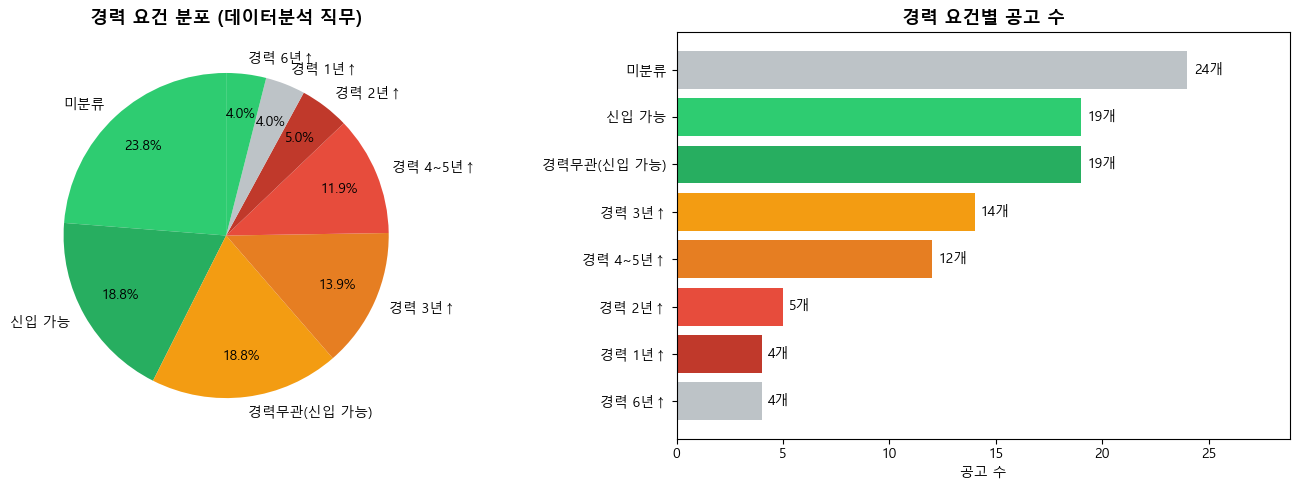


✅ 신입 지원 가능 공고: 38개 (37.6%)
⚠️  경력직만 가능한 공고: 63개


In [6]:
def classify_career(text):
    t = str(text)
    if re.search(r"신입", t): 
        return "신입 가능"
    if re.search(r"경력무관", t): 
        return "경력무관(신입 가능)"
    if re.search(r"경력1년|경력 1년", t): 
        return "경력 1년↑"
    if re.search(r"경력2년|경력 2년", t): 
        return "경력 2년↑"
    if re.search(r"경력3년|경력 3년", t): 
        return "경력 3년↑"
    if re.search(r"경력[4-5]년|경력 [4-5]년", t): 
        return "경력 4~5년↑"
    if re.search(r"경력[6-9]년|경력 [6-9]년|경력1[0-9]년", t): 
        return "경력 6년↑"
    return "미분류"

df_da["경력분류"] = df_da["경력"].apply(classify_career)

career_counts = df_da["경력분류"].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 파이차트
colors = ["#2ecc71", "#27ae60", "#f39c12", "#e67e22", "#e74c3c", "#c0392b", "#bdc3c7"]
axes[0].pie(career_counts.values, labels=career_counts.index,
            autopct="%1.1f%%", colors=colors[:len(career_counts)],
            startangle=90, pctdistance=0.75)
axes[0].set_title("경력 요건 분포 (데이터분석 직무)", fontsize=13, fontweight="bold")

# 바차트
bars = axes[1].barh(career_counts.index[::-1], career_counts.values[::-1], color=colors[:len(career_counts)][::-1])
for bar, val in zip(bars, career_counts.values[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f"{val}개", va="center", fontsize=10)
axes[1].set_xlabel("공고 수")
axes[1].set_title("경력 요건별 공고 수", fontsize=13, fontweight="bold")
axes[1].set_xlim(0, max(career_counts.values) * 1.2)

plt.tight_layout()
plt.savefig("chart_career.png", dpi=150, bbox_inches="tight")
plt.show()

# 신입 지원 가능 공고 수
newbie_ok = df_da[df_da["경력분류"].isin(["신입 가능", "경력무관(신입 가능)"])]
print(f"\n✅ 신입 지원 가능 공고: {len(newbie_ok)}개 ({len(newbie_ok)/len(df_da)*100:.1f}%)")
print(f"⚠️  경력직만 가능한 공고: {len(df_da) - len(newbie_ok)}개")

## 4. 지역별 분포 — 어디서 뽑나?

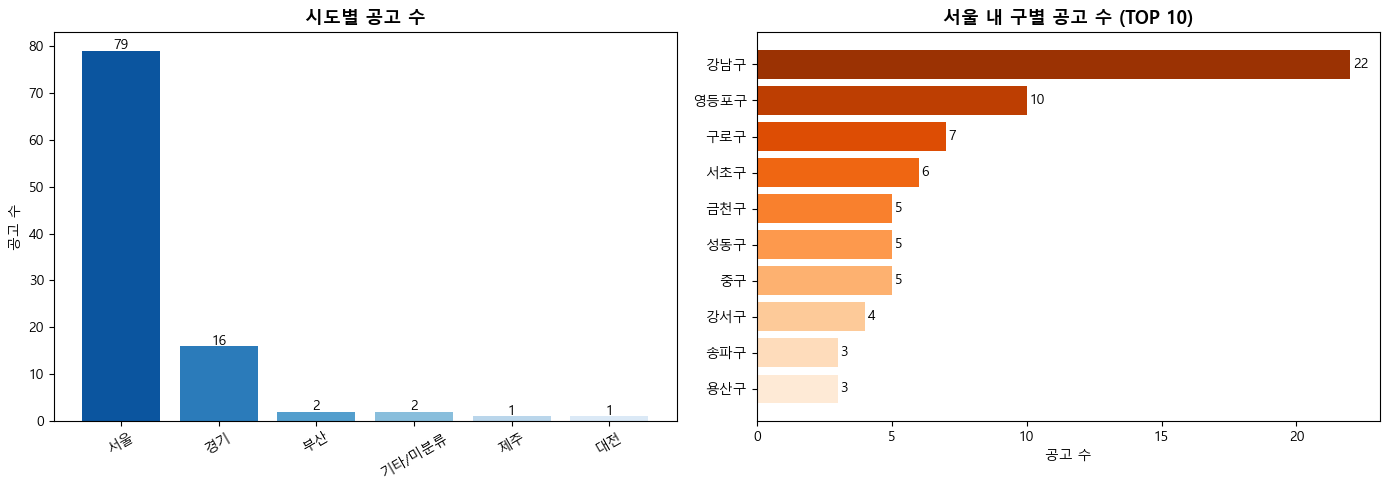

서울 집중도: 79/101 (78.2%)


In [7]:
def extract_city(text):
    t = str(text)
    # 서울 구 단위 → "서울"로 통합
    if "서울" in t: return "서울"
    if "경기" in t: return "경기"
    if "부산" in t: return "부산"
    if "인천" in t: return "인천"
    if "대구" in t: return "대구"
    if "대전" in t: return "대전"
    if "광주" in t: return "광주"
    if "울산" in t: return "울산"
    if "세종" in t: return "세종"
    if "제주" in t: return "제주"
    return "기타/미분류"

df_da["시도"] = df_da["지역"].apply(extract_city)

# 서울 내 구별 분석
seoul_mask = df_da["지역"].str.contains("서울", na=False)
seoul_gu = df_da[seoul_mask]["지역"].str.extract(r"서울\s*(\S+구)")[0].dropna()
seoul_gu_counts = seoul_gu.value_counts().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 시도별
city_counts = df_da["시도"].value_counts()
palette = sns.color_palette("Blues_r", len(city_counts))
axes[0].bar(city_counts.index, city_counts.values, color=palette)
for i, (x, v) in enumerate(zip(city_counts.index, city_counts.values)):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=10)
axes[0].set_title("시도별 공고 수", fontsize=13, fontweight="bold")
axes[0].set_ylabel("공고 수")
axes[0].tick_params(axis="x", rotation=30)

# 서울 내 구별
palette2 = sns.color_palette("Oranges_r", len(seoul_gu_counts))
axes[1].barh(seoul_gu_counts.index[::-1], seoul_gu_counts.values[::-1], color=palette2[::-1])
for i, (y, v) in enumerate(zip(seoul_gu_counts.index[::-1], seoul_gu_counts.values[::-1])):
    axes[1].text(v + 0.1, i, str(v), va="center", fontsize=10)
axes[1].set_title("서울 내 구별 공고 수 (TOP 10)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("공고 수")

plt.tight_layout()
plt.savefig("chart_location.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"서울 집중도: {city_counts.get('서울', 0)}/{len(df_da)} ({city_counts.get('서울', 0)/len(df_da)*100:.1f}%)")

## 5. 기술스택(스킬) 분석 — 가장 많이 요구되는 기술은?

데이터 분석가가 되려면 **어떤 기술을 배워야 하는지** 확인합니다.

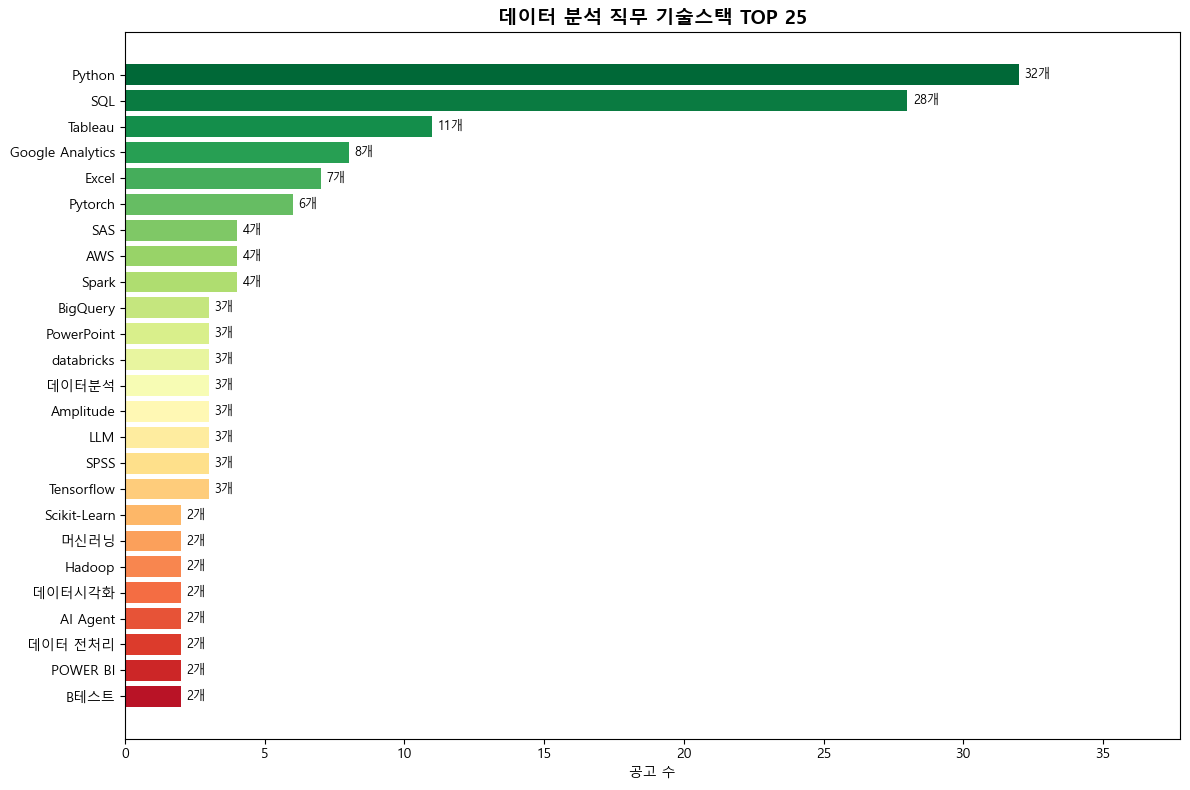

TOP 15 스킬:
   1. Python               32개
   2. SQL                  28개
   3. Tableau              11개
   4. Google Analytics     8개
   5. Excel                7개
   6. Pytorch              6개
   7. SAS                  4개
   8. AWS                  4개
   9. Spark                4개
  10. BigQuery             3개
  11. PowerPoint           3개
  12. databricks           3개
  13. 데이터분석                3개
  14. Amplitude            3개
  15. LLM                  3개


In [8]:
def extract_skills(series):
    all_skills = []
    for val in series.dropna():
        # "/ " 로 구분된 것도 처리
        raw = str(val).replace(" / ", ", ").replace("/", ", ")
        skills = [s.strip() for s in raw.split(",") if s.strip()]
        all_skills.extend(skills)
    return all_skills

# 전체 스킬 카운트
all_skills = extract_skills(df_da["스킬"])
skill_counter = Counter(all_skills)

# 비의미 단어 제외
EXCLUDE_SKILLS = {"nan", "", "운전면허", "1종보통운전면허", "2종보통운전면허",
                  "비즈니스영어", "영어회화", "TOEIC", "영어", "일본어", "중국어",
                  "워드", "OA", "Microsoft Office", "컴퓨터활용", "컴퓨터활용능력",
                  "SNS관리", "SNS활용", "Photoshop", "Illustrator", "프리미어"}
filtered = {k: v for k, v in skill_counter.items() if k not in EXCLUDE_SKILLS and len(k) > 1}
skill_df = pd.DataFrame(filtered.items(), columns=["스킬", "빈도"]).sort_values("빈도", ascending=False)

TOP_N = 25
top_skills = skill_df.head(TOP_N)

fig, ax = plt.subplots(figsize=(12, 8))
colors = plt.cm.RdYlGn_r([i / TOP_N for i in range(TOP_N)])
bars = ax.barh(top_skills["스킬"][::-1], top_skills["빈도"][::-1], color=colors[::-1])
for bar, val in zip(bars, top_skills["빈도"][::-1]):
    ax.text(bar.get_width() + 0.2, bar.get_y() + bar.get_height()/2,
            f"{val}개", va="center", fontsize=9)
ax.set_xlabel("공고 수")
ax.set_title(f"데이터 분석 직무 기술스택 TOP {TOP_N}", fontsize=14, fontweight="bold")
ax.set_xlim(0, top_skills["빈도"].max() * 1.18)
plt.tight_layout()
plt.savefig("chart_skills.png", dpi=150, bbox_inches="tight")
plt.show()

print("TOP 15 스킬:")
for i, (_, row) in enumerate(top_skills.head(15).iterrows(), 1):
    print(f"  {i:2d}. {row['스킬']:20s} {row['빈도']}개")

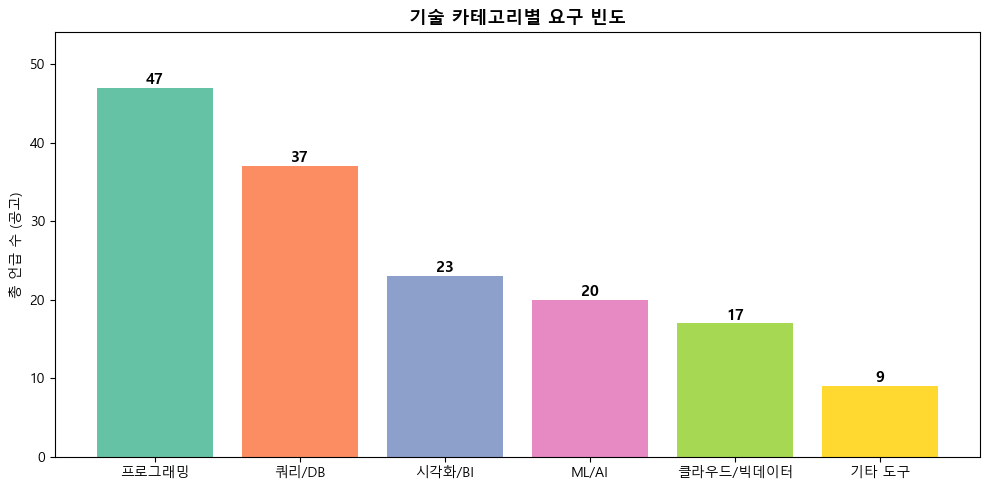

In [9]:
# 스킬 카테고리별 분류 시각화
SKILL_CATS = {
    "쿼리/DB":        ["SQL", "MySQL", "Oracle", "PostgreSQL", "MSSQL", "Hive", "NoSQL", "RDBMS", "DBMS"],
    "프로그래밍":      ["Python", "R", "Scala", "SAS", "SPSS"],
    "시각화/BI":       ["Tableau", "Power BI", "powerBI", "Looker", "Redash", "Amplitude", "Google Analytics", "Grafana", "Metabase"],
    "클라우드/빅데이터": ["AWS", "GCP", "Azure", "Spark", "Hadoop", "Kafka", "BigQuery", "Airflow", "Databricks"],
    "ML/AI":          ["Pytorch", "Tensorflow", "Scikit-Learn", "머신러닝", "딥러닝", "LLM", "RAG", "NLP", "LLMOps", "AI모델"],
    "기타 도구":       ["Excel", "Notion", "Git", "Figma", "AppsFlyer", "Lever"],
}

cat_counts = {}
for cat, keywords in SKILL_CATS.items():
    count = sum(skill_counter.get(k, 0) for k in keywords)
    cat_counts[cat] = count

cat_df = pd.DataFrame(cat_counts.items(), columns=["카테고리", "총 언급수"]).sort_values("총 언급수", ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
palette = sns.color_palette("Set2", len(cat_df))
bars = ax.bar(cat_df["카테고리"], cat_df["총 언급수"], color=palette)
for bar, val in zip(bars, cat_df["총 언급수"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            str(val), ha="center", fontsize=11, fontweight="bold")
ax.set_title("기술 카테고리별 요구 빈도", fontsize=13, fontweight="bold")
ax.set_ylabel("총 언급 수 (공고)")
ax.set_ylim(0, cat_df["총 언급수"].max() * 1.15)
plt.tight_layout()
plt.savefig("chart_skill_category.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. 우대 자격증 분석 — 따두면 좋은 자격증은?

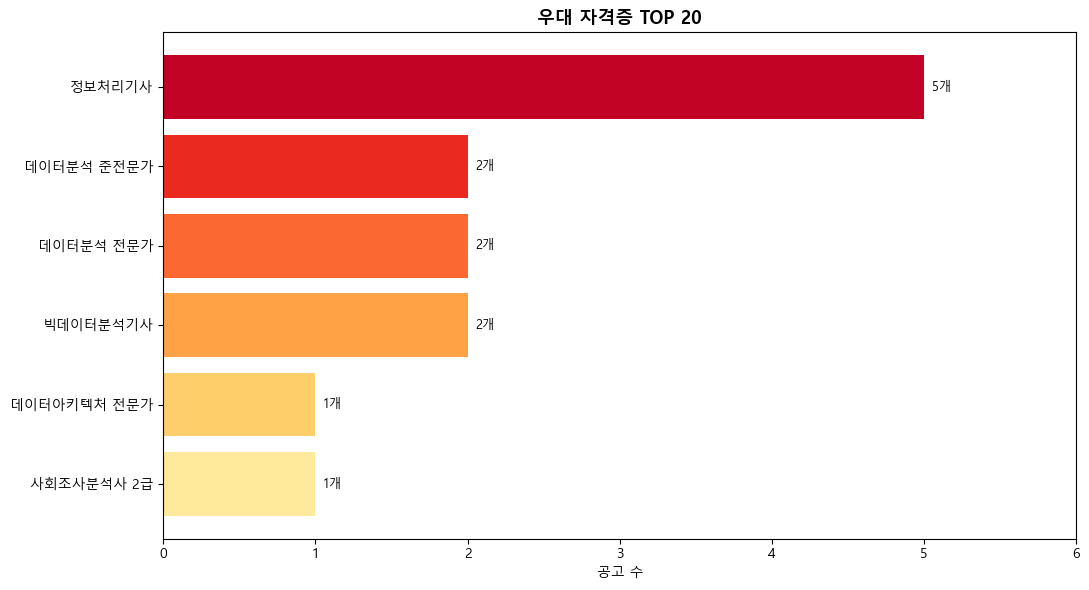

우대 자격증 순위:
   1. 정보처리기사                    5개
   2. 데이터분석 준전문가                2개
   3. 데이터분석 전문가                 2개
   4. 빅데이터분석기사                  2개
   5. 데이터아키텍처 전문가               1개
   6. 사회조사분석사 2급                1개


In [10]:
def extract_certs(series):
    certs = []
    for val in series.dropna():
        parts = [s.strip() for s in str(val).split(",") if s.strip() and s.strip() != "nan"]
        certs.extend(parts)
    return certs

certs = extract_certs(df_da["우대_자격증"])
cert_counter = Counter(certs)

# 스킬 항목이 잘못 들어간 것들 제거 (길이가 너무 길거나 숫자만인 것)
cert_filtered = {k: v for k, v in cert_counter.items()
                 if len(k) >= 2 and len(k) <= 30 and not k.isdigit()}
cert_df = pd.DataFrame(cert_filtered.items(), columns=["자격증", "빈도"]).sort_values("빈도", ascending=False).head(20)

if len(cert_df) > 0:
    fig, ax = plt.subplots(figsize=(11, 6))
    palette = sns.color_palette("YlOrRd_r", len(cert_df))
    bars = ax.barh(cert_df["자격증"][::-1], cert_df["빈도"][::-1], color=palette[::-1])
    for bar, val in zip(bars, cert_df["빈도"][::-1]):
        ax.text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                f"{val}개", va="center", fontsize=9)
    ax.set_xlabel("공고 수")
    ax.set_title("우대 자격증 TOP 20", fontsize=13, fontweight="bold")
    ax.set_xlim(0, cert_df["빈도"].max() * 1.2)
    plt.tight_layout()
    plt.savefig("chart_certs.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print("우대 자격증 순위:")
    for i, (_, row) in enumerate(cert_df.iterrows(), 1):
        print(f"  {i:2d}. {row['자격증']:25s} {row['빈도']}개")
else:
    print("자격증 데이터가 충분하지 않습니다.")

## 7. 우대 조건 키워드 분석 — 기업이 선호하는 사람은?

In [12]:
! pip install WordCloud

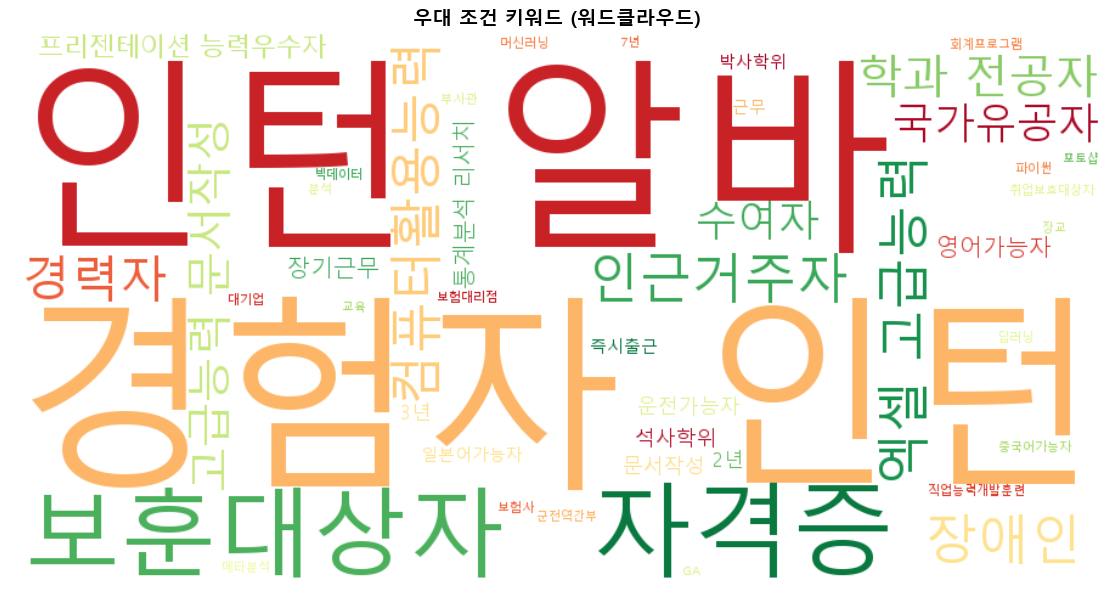

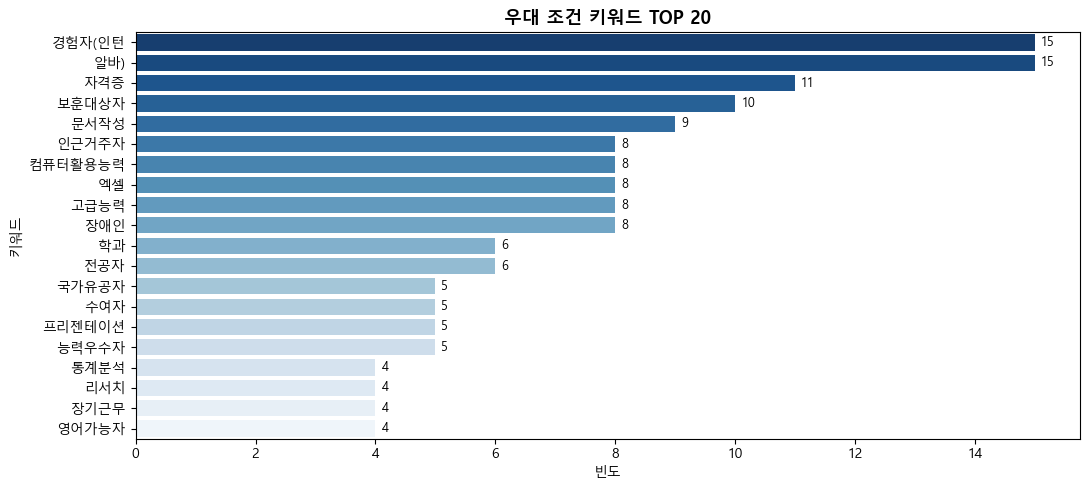

In [13]:
from wordcloud import WordCloud
import numpy as np

# 우대조건 전체 텍스트 합치기
pref_text = " ".join(df_da["우대_기본"].dropna().astype(str))

# 단어 빈도 계산 (간단 토크나이징)
def tokenize_korean(text):
    # 의미없는 단어 제거
    stopwords = {"자", "가능", "및", "이상", "이하", "보유", "능력", "우수자", "가능자",
                 "보유자", "능숙자", "경험자", "유관업무", "관련", "있는", "있으신", "분",
                 "경우", "기타", "기업", "회사", "직무", "업무", "수행", "경력자"}
    tokens = re.split(r"[,·\s/]+", text)
    return [t.strip() for t in tokens
            if t.strip() and len(t.strip()) >= 2 and t.strip() not in stopwords]

tokens = tokenize_korean(pref_text)
token_counter = Counter(tokens)

# 워드클라우드
wc_text = " ".join(tokens)
try:
    # 한글 폰트 경로 찾기
    font_paths = [f.fname for f in fm.fontManager.ttflist
                  if any(k in f.name for k in ["Malgun", "맑은", "NanumGothic", "나눔"])]
    font_path = font_paths[0] if font_paths else None
    
    wc = WordCloud(
        font_path=font_path,
        width=900, height=450,
        background_color="white",
        colormap="RdYlGn",
        max_words=80,
    ).generate(wc_text)
    
    fig, ax = plt.subplots(figsize=(14, 6))
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title("우대 조건 키워드 (워드클라우드)", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("chart_wordcloud.png", dpi=150, bbox_inches="tight")
    plt.show()
except Exception as e:
    print(f"워드클라우드 생성 실패: {e}")

# TOP 키워드 바차트
top_tokens = pd.DataFrame(token_counter.most_common(20), columns=["키워드", "빈도"])
fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=top_tokens, x="빈도", y="키워드", palette="Blues_r", ax=ax)
ax.set_title("우대 조건 키워드 TOP 20", fontsize=13, fontweight="bold")
for i, v in enumerate(top_tokens["빈도"]):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.savefig("chart_pref_keywords.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. 핵심역량 분석 — 기업이 원하는 인재상

기술 외에 기업이 중요하게 여기는 **소프트 스킬**을 파악합니다.

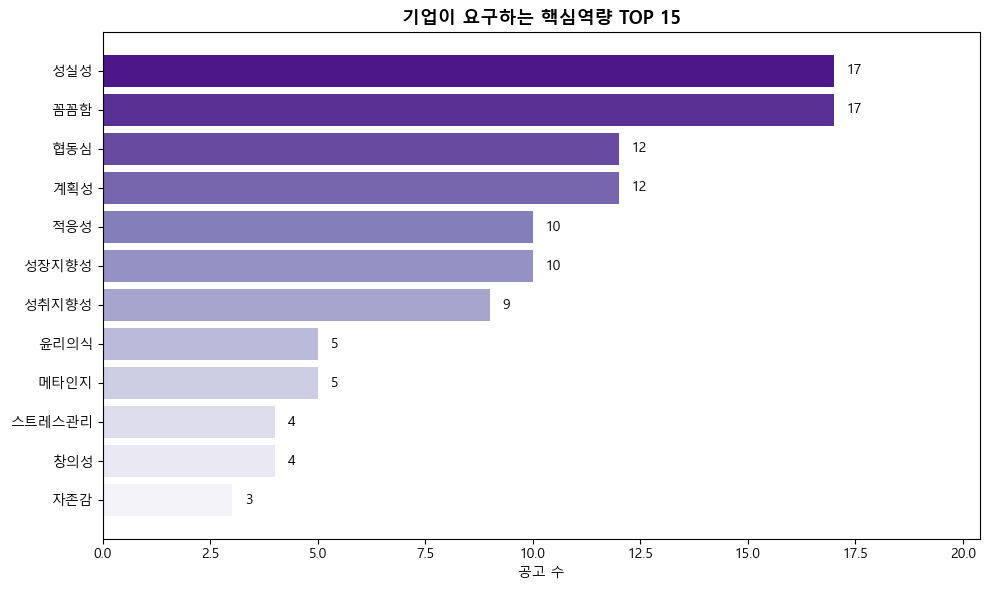

핵심역량 TOP 10:
   1. 성실성             17개 공고
   2. 꼼꼼함             17개 공고
   3. 협동심             12개 공고
   4. 계획성             12개 공고
   5. 적응성             10개 공고
   6. 성장지향성           10개 공고
   7. 성취지향성           9개 공고
   8. 윤리의식            5개 공고
   9. 메타인지            5개 공고
  10. 스트레스관리          4개 공고


In [14]:
def extract_competencies(series):
    result = []
    for val in series.dropna():
        cleaned = re.sub(r",\s*,", ",", str(val))  # 쉼표 연속 제거
        parts = [s.strip().rstrip(",") for s in cleaned.split(",") if s.strip().rstrip(",")]
        result.extend(parts)
    return result

comps = extract_competencies(df_da["핵심역량"])
comp_counter = Counter(comps)

# 의미없는 항목 제거
comp_filtered = {k: v for k, v in comp_counter.items()
                 if len(k) >= 2 and k != "nan"}
comp_df = pd.DataFrame(comp_filtered.items(), columns=["역량", "빈도"]).sort_values("빈도", ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.color_palette("Purples_r", len(comp_df))
bars = ax.barh(comp_df["역량"][::-1], comp_df["빈도"][::-1], color=colors[::-1])
for bar, val in zip(bars, comp_df["빈도"][::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f"{val}", va="center", fontsize=10)
ax.set_xlabel("공고 수")
ax.set_title("기업이 요구하는 핵심역량 TOP 15", fontsize=13, fontweight="bold")
ax.set_xlim(0, comp_df["빈도"].max() * 1.2)
plt.tight_layout()
plt.savefig("chart_competency.png", dpi=150, bbox_inches="tight")
plt.show()

print("핵심역량 TOP 10:")
for i, (_, row) in enumerate(comp_df.head(10).iterrows(), 1):
    print(f"  {i:2d}. {row['역량']:15s} {row['빈도']}개 공고")

## 9. 급여 분포 — 데이터 분석가 연봉은?

급여 정보 있는 공고: 10개


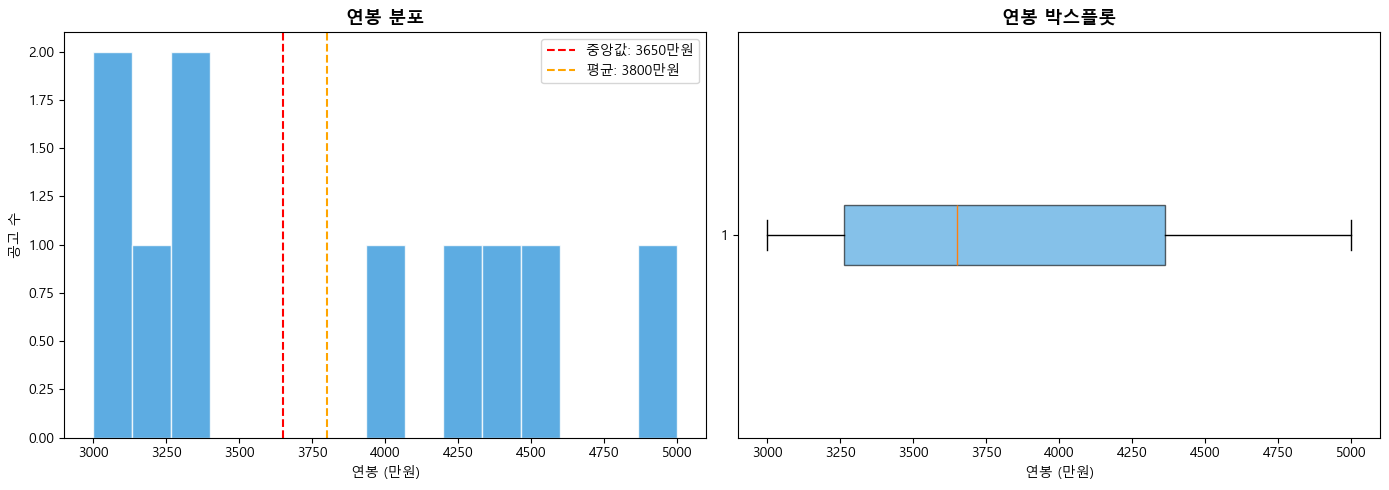


연봉 통계 (n=10)
  최소: 3000만원
  최대: 5000만원
  평균: 3800만원
  중앙값: 3650만원

공고별 급여 목록:
  연봉 4,000~6,000만원
  연봉 3,000~6,000만원
  연봉 3,800~5,000만원
  연봉 4,000~4,500만원
  연봉 4,000만원~
  연봉 3,000~3,600만원
  연봉 3,300만원~
  연봉 3,000~3,500만원
  연봉 3,000만원~
  연봉 3,000만원~


In [15]:
salary_raw = df_da["급여"].dropna().astype(str)
salary_raw = salary_raw[salary_raw.str.contains("만원|억", na=False)]

def parse_salary_range(text):
    """'연봉 3,500~5,000만원' → (3500, 5000) 형태로 파싱"""
    t = text.replace(",", "").replace(" ", "")
    # 범위 형태: 3500~5000만원
    m = re.search(r"(\d{3,5})~(\d{3,5})만원", t)
    if m:
        return (int(m.group(1)), int(m.group(2)))
    # 단일 값: 4000만원 이상
    m = re.search(r"(\d{3,5})만원", t)
    if m:
        v = int(m.group(1))
        return (v, v)
    # 억 단위
    m = re.search(r"(\d+)억", t)
    if m:
        v = int(m.group(1)) * 10000
        return (v, v)
    return None

salary_parsed = []
for s in salary_raw:
    result = parse_salary_range(s)
    if result:
        lo, hi = result
        if 1000 <= lo <= 20000:  # 합리적 범위 필터
            salary_parsed.append({"원문": s, "최소": lo, "최대": hi, "중간": (lo + hi) / 2})

salary_df = pd.DataFrame(salary_parsed)
print(f"급여 정보 있는 공고: {len(salary_df)}개")

if len(salary_df) >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 히스토그램
    axes[0].hist(salary_df["중간"], bins=15, color="#3498db", edgecolor="white", alpha=0.8)
    axes[0].axvline(salary_df["중간"].median(), color="red", linestyle="--",
                    label=f"중앙값: {salary_df['중간'].median():.0f}만원")
    axes[0].axvline(salary_df["중간"].mean(), color="orange", linestyle="--",
                    label=f"평균: {salary_df['중간'].mean():.0f}만원")
    axes[0].set_xlabel("연봉 (만원)")
    axes[0].set_ylabel("공고 수")
    axes[0].set_title("연봉 분포", fontsize=13, fontweight="bold")
    axes[0].legend()
    
    # 박스플롯
    axes[1].boxplot(salary_df["중간"], vert=False, patch_artist=True,
                    boxprops=dict(facecolor="#3498db", alpha=0.6))
    axes[1].set_xlabel("연봉 (만원)")
    axes[1].set_title("연봉 박스플롯", fontsize=13, fontweight="bold")
    
    plt.tight_layout()
    plt.savefig("chart_salary.png", dpi=150, bbox_inches="tight")
    plt.show()
    
    print(f"\n연봉 통계 (n={len(salary_df)})")
    print(f"  최소: {salary_df['중간'].min():.0f}만원")
    print(f"  최대: {salary_df['중간'].max():.0f}만원")
    print(f"  평균: {salary_df['중간'].mean():.0f}만원")
    print(f"  중앙값: {salary_df['중간'].median():.0f}만원")
    print()
    print("공고별 급여 목록:")
    for _, row in salary_df.sort_values("중간", ascending=False).iterrows():
        print(f"  {row['원문']}")
else:
    print("급여 공개 공고가 적어 통계가 어렵습니다.")
    print("공개된 급여 목록:")
    for s in salary_raw.values:
        print(f"  {s}")

## 10. 신입 지원 가능 공고 정리 & 취업 전략 요약

지금까지 분석한 결과를 바탕으로 **신입 데이터 분석가 취업 전략**을 정리합니다.

신입 지원 가능 공고: 38개

→ 'jobkorea_newbie_jobs.csv' 저장 완료



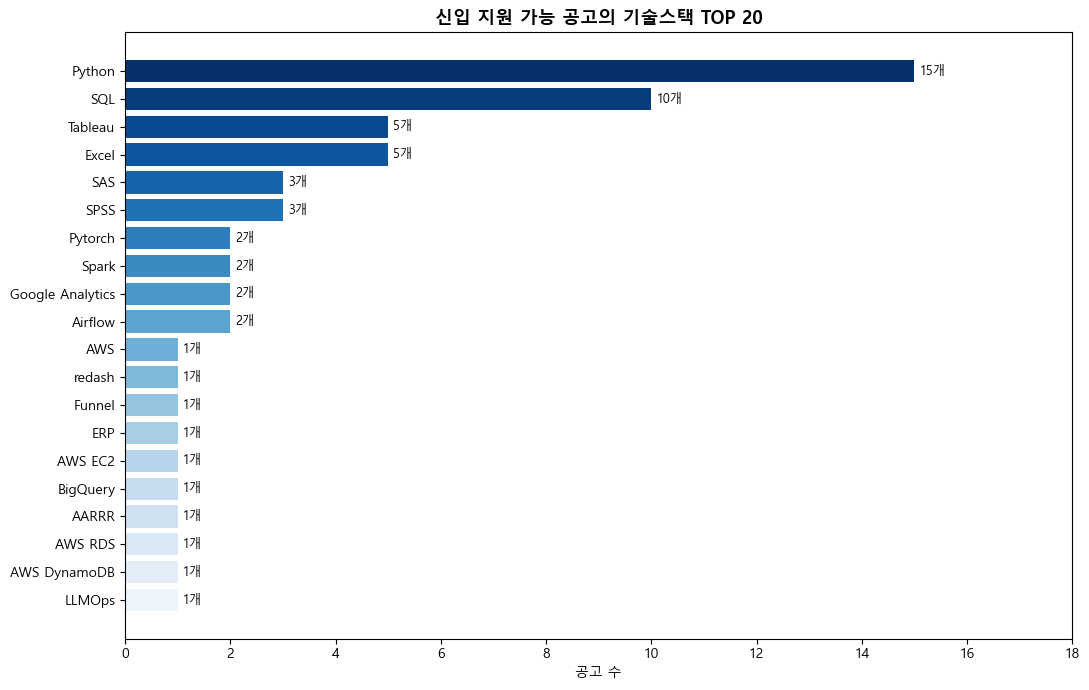


=== 신입 지원 공고 목록 ===


,회사명,공고제목,스킬,마감일
0,넛지헬스케어㈜,[캐시워크] 데이터분석 담당 채용전환형 인턴,"AWS, Python, SQL, Tableau, AWS EC2, AWS RDS, A...",상시채용
1,㈜진학사,[진학사] 모의지원 / 합격예측 데이터분석 인재 채용 (경력무관),"Python, SQL",03/02(월) 마감
2,넛지헬스케어㈜,[캐시워크-병역특례] 데이터분석 담당 산업기능요원,"Python, SQL, Tableau, / redash",상시채용
3,㈜에이젝코리아,[일본계/시청역] 마케팅/데이터분석 신입/경력 채용(일본어가능자),NaN,내일마감
4,리딩스타㈜,[정규직] 리딩스타 경영본부 데이터분석 사업지원 담당 모집,NaN,03/14(토) 마감
5,㈜네피리티,[(주)네피리티/제주] 데이터분석 및 AI모델 개발 모집,Python,03/12(목) 마감
6,㈜파오스파트너스,"(주)파오스파트너스 -DB관리, DB생성, DB분석 채용","Tableau, / powerBI",04/07(화) 마감
7,㈜네피리티,[(주)네피리티/서울] 데이터분석 및 AI모델 개발 모집,Python,03/12(목) 마감
8,㈜싸이트플래닝건축사사무소,도시공학& 데이터분석 공고 모집 (정규직) [부산],Illustrator,03/22(일) 마감
9,글로빛㈜,"[글로빛] 빅데이터분석,AI(머신러닝,딥러닝) 가능한 박사님 모십니다",NaN,상시채용


In [16]:
# 신입 지원 가능 공고만 별도 저장
newbie_cols = ["회사명", "공고제목", "경력", "지역", "스킬", "우대_기본", "우대_자격증", "급여", "마감일", "링크"]
newbie_df = df_da[df_da["경력분류"].isin(["신입 가능", "경력무관(신입 가능)"])][newbie_cols]

print(f"신입 지원 가능 공고: {len(newbie_df)}개")
print()
newbie_df.to_csv("jobkorea_newbie_jobs.csv", index=False, encoding="utf-8-sig")
print("→ 'jobkorea_newbie_jobs.csv' 저장 완료")
print()

# 신입 공고의 필수 스킬 재분석
newbie_skills = extract_skills(newbie_df["스킬"])
ns_counter = Counter(newbie_skills)
ns_filtered = {k: v for k, v in ns_counter.items()
               if k not in EXCLUDE_SKILLS and len(k) > 1}
ns_df = pd.DataFrame(ns_filtered.items(), columns=["스킬", "빈도"]).sort_values("빈도", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 7))
colors = plt.cm.Blues_r([i / len(ns_df) for i in range(len(ns_df))])
bars = ax.barh(ns_df["스킬"][::-1], ns_df["빈도"][::-1], color=colors[::-1])
for bar, val in zip(bars, ns_df["빈도"][::-1]):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            f"{val}개", va="center", fontsize=9)
ax.set_xlabel("공고 수")
ax.set_title("신입 지원 가능 공고의 기술스택 TOP 20", fontsize=13, fontweight="bold")
ax.set_xlim(0, ns_df["빈도"].max() * 1.2)
plt.tight_layout()
plt.savefig("chart_newbie_skills.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n=== 신입 지원 공고 목록 ===")
display(newbie_df[["회사명", "공고제목", "스킬", "마감일"]].reset_index(drop=True))

## 🎯 신입 데이터 분석가 취업 전략 요약

> 위 분석 결과를 기반으로 한 실전 로드맵

In [17]:
summary = f"""
╔══════════════════════════════════════════════════════════════╗
║         신입 데이터 분석가 취업 전략 요약                    ║
╚══════════════════════════════════════════════════════════════╝

📌 [분석 대상]
   전체 공고 {len(df)}개 → 데이터분석 직무 {len(df_da)}개 필터링

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔑 [필수 기술 스택 — 이것만은 꼭 배우자]

   1순위 (거의 모든 공고에서 요구):
     · SQL      — 데이터 추출/조회의 기본 중의 기본
     · Python   — 분석, 전처리, 시각화 필수
     · Excel    — 여전히 현업에서 많이 사용

   2순위 (경쟁력을 높이는 기술):
     · Tableau / Power BI  — 시각화·대시보드 도구
     · Google Analytics    — 마케팅·서비스 분석 필수
     · AWS / BigQuery      — 클라우드 데이터 환경
     · Spark / Hadoop      — 빅데이터 처리

   3순위 (차별화 포인트):
     · PyTorch / TensorFlow — ML/AI 모델링
     · Airflow              — 파이프라인 자동화
     · Amplitude / Looker   — 프로덕트 분석

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 [우대 자격증 — 딸 것들]
   · SQLD (SQL 개발자)         — 가장 자주 언급
   · ADsP (데이터분석 준전문가) — 입문용 데이터 자격증
   · ADP  (데이터분석 전문가)   — 고급
   · 정보처리기사               — IT 전반 기초

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🧠 [기업이 원하는 인재상 — 소프트 스킬]
   · 성실성 / 꼼꼼함        — 1, 2위 압도적
   · 협동심 / 커뮤니케이션  — 팀워크 중요
   · 성장지향성 / 창의성    — 자기계발 의지
   → 이력서/자소서에 이 키워드들을 반영하세요!

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📍 [취업 타깃 지역]
   · 서울 집중 (약 70%+)
   · 서울 내: 강남구 > 마포구 > 서초구 > 영등포구 순

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📋 [신입 공략 전략]
   1. SQL + Python 포트폴리오 프로젝트 1~2개 제작
   2. SQLD 또는 ADsP 자격증 취득
   3. 공공데이터(data.go.kr) or Kaggle로 분석 경험 쌓기
   4. Tableau / Power BI 대시보드 결과물 포트폴리오 추가
   5. "경력무관" 공고부터 집중 지원 → 경력 쌓기
   6. 중소기업에서 경력 시작 후 이직 전략도 유효

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📂 저장 파일:
   · jobkorea_newbie_jobs.csv  — 신입 지원 가능 공고 목록
   · chart_*.png               — 분석 차트 이미지들
"""

print(summary)


╔══════════════════════════════════════════════════════════════╗
║         신입 데이터 분석가 취업 전략 요약                    ║
╚══════════════════════════════════════════════════════════════╝

📌 [분석 대상]
   전체 공고 202개 → 데이터분석 직무 101개 필터링

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🔑 [필수 기술 스택 — 이것만은 꼭 배우자]

   1순위 (거의 모든 공고에서 요구):
     · SQL      — 데이터 추출/조회의 기본 중의 기본
     · Python   — 분석, 전처리, 시각화 필수
     · Excel    — 여전히 현업에서 많이 사용

   2순위 (경쟁력을 높이는 기술):
     · Tableau / Power BI  — 시각화·대시보드 도구
     · Google Analytics    — 마케팅·서비스 분석 필수
     · AWS / BigQuery      — 클라우드 데이터 환경
     · Spark / Hadoop      — 빅데이터 처리

   3순위 (차별화 포인트):
     · PyTorch / TensorFlow — ML/AI 모델링
     · Airflow              — 파이프라인 자동화
     · Amplitude / Looker   — 프로덕트 분석

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

🏆 [우대 자격증 — 딸 것들]
   · SQLD (SQL 개발자)         — 가장 자주 언급
   · ADsP (데이터분석 준전문가) — 입문용 데이터 자격증
   · ADP  (데이터분석 전문가)   — 고급
   · 정보처리기사               — IT 전반 기초

━━━━━━━━━━━━━━